In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("torch").setLevel(logging.ERROR)

## Overview
- Apply text classification on Vietnamese Curated Dataset, with few sample files to save resource

## EDA
- Because of subsample, make sure they have varied labels and distribution are fine 

In [2]:
input_df_1=pd.read_parquet('data/raw/train-00000-of-00132.parquet')

In [3]:
input_df_1.shape

(92191, 3)

In [4]:
input_df_1['domain'].value_counts(dropna=False)

domain
Arts_and_Entertainment       7261
Sensitive_Subjects           6612
Health                       6546
People_and_Society           6323
Sports                       6116
News                         5970
Food_and_Drink               5125
Business_and_Industrial      4747
Travel_and_Transportation    4407
Jobs_and_Education           4256
Beauty_and_Fitness           4000
Home_and_Garden              3719
Computers_and_Electronics    3589
Law_and_Government           2897
Internet_and_Telecom         2804
Books_and_Literature         2678
Games                        2548
Autos_and_Vehicles           2508
Finance                      2446
Real_Estate                  2263
Pets_and_Animals             1532
Science                      1436
Shopping                     1310
Hobbies_and_Leisure           732
Online_Communities            366
Name: count, dtype: int64

In [7]:
input_df_2=pd.read_parquet('data/raw/train-00001-of-00132.parquet')

In [8]:
input_df_2.shape

(92191, 3)

In [9]:
input_df_2['domain'].value_counts(dropna=False)

domain
Arts_and_Entertainment       7065
Health                       6729
People_and_Society           6354
News                         5794
Sports                       5616
Sensitive_Subjects           5323
Food_and_Drink               5179
Business_and_Industrial      4727
Travel_and_Transportation    4522
Beauty_and_Fitness           4388
Jobs_and_Education           4315
Home_and_Garden              4118
Computers_and_Electronics    3916
Books_and_Literature         3259
Internet_and_Telecom         3056
Law_and_Government           2692
Real_Estate                  2635
Autos_and_Vehicles           2492
Games                        2437
Finance                      2374
Shopping                     1475
Pets_and_Animals             1292
Science                      1276
Hobbies_and_Leisure           754
Online_Communities            403
Name: count, dtype: int64

In [10]:
[i for i in input_df_2['domain'].unique() if i not in input_df_1['domain'].unique()]

[]

In [11]:
[i for i in input_df_1['domain'].unique() if i not in input_df_2['domain'].unique()]

[]

In [12]:
len(input_df_2['domain'].unique())

25

In [11]:
print(input_df_1['text'][0])

Internet Society hay ISOC là một tổ chức quốc tế hoạt động phi lợi nhuận, phi chính phủ và bao gồm các thành viên có trình độ chuyên ngành. Tổ chức này chú trọng đến: tiêu chuẩn, giáo dục và các vấn đề về chính sách. Với trên 145 tổ chức thành viên và 65.000 thành viên cá nhân, ISOC bao gồm những con người cụ thể trong cộng đồng Internet. Mọi chi tiết có thể tìm thấy tại website của ISOC.

Internet Society nằm ở gần thủ đô Washington, DC, Hoa Kỳ và Geneva, Thụy Sĩ. Số hội viên của nó bao gồm hơn 145 tổ chức thành viên và hơn 65.000 cá nhân. Thành viên còn có thể tự lập một chi nhánh của tổ chức tùy theo vị trí hoặc sở thích. Hiện nay tổ chức có tới 90 chi nhánh trên toàn thế giới.

Nhiệm vụ và mục đích hoạt động
Bảo đảm, cổ vũ cho sự phát triển, mở rộng và sử dụng Internet được thuận lợi nhất cho mọi người trên toàn thế giới.

Xem thêm
Lịch sử Internet

Tham khảo

Liên kết ngoài
 
 
 ISOC Việt Nam
 IETF and the Internet Society - Về Internet Engineering Task Force và ISOC, bài của Vint

In [12]:
print(input_df_2['text'][1000])

Bón NPK-S Lâm Thao cho cây cà rốt?
Chủ nhật, 18/03/2018 05:04 GMT+7
10/12/2013, 11:40 (GMT+7)
Để tạo năng suất như trong SX, cây cà rốt lấy đi từ đất lượng đạm thuộc loại nhiều (chia làm 5 nhóm rau, cây cà rốt ở nhóm đầu), kali và lân thuộc loại trung bình thấp (nhóm thứ 3 của 4 nhóm).
Cây cà rốt có tên khoa học là Daucus carota var. sativa thuộc họ Hoa tán Umbelliferae.
Cây cà rốt được trồng đầu tiên ở Afghanistan và sau đó được trồng ở 10 - 12 nước khu vực phía Đông vùng Địa Trung Hải, rồi chuyển ra phía Tây khoảng 14 - 15 nước Châu Âu. Cây cà rốt được sử dụng từ lâu, đầu tiên được coi là cây thuốc, mãi cho đến những năm đầu thế kỷ XX mới được sử dụng làm cây thực phẩm. Cà rốt nổi tiếng vì là nguồn dồi dào vitaminA, hàm lượng vitamin B1, C và B2 cũng rất khá.
Cà rốt là cây rau ăn củ, năng suất củ giảm mạnh nếu giai đoạn phình củ thiếu nước. Cà rốt là cây chịu lạnh, ưu thích nhiệt độ 16 - 210C, tuy nhiên có thể chịu được nhiệt độ cao 25 - 270C, ở nhiệt độ thích hợp củ phát triển to, n

### Split sentences

In [13]:
import re
from typing import List, Optional

def split_into_sentences(
    text: str,
    min_sentence_length: int = 10,
    max_sentence_length: int = 1000,
    preserve_acronyms: bool = True,
) -> List[str]:
    """
    Split text into sentences, handling edge cases like:
    - Acronyms (U.S.A., Dr., Mr., etc.)
    - Numbers with decimals/periods (3.14, $1.99)
    - Abbreviations (e.g., i.e., vs.)
    - URLs and email addresses
    - Quotation marks and parentheses
    - Bullet points and list items
    """
    if not text or not text.strip():
        return []
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text.strip())
    
    # Protect abbreviations from being split
    abbreviations = [
        r'\b(?:Mr|Mrs|Ms|Miss|Dr|Prof|Sr|Jr|St|Ave|Blvd|Dept|Univ|Corp|Inc|Ltd|Co)\.',
        r'\b(?:etc|vs|approx|dept|est|govt|natl|orig|temp)\.',
        r'\b(?:Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\.',
        r'\b[A-Z]\.(?:\s[A-Z]\.)*',  # U.S.A., F.B.I.
    ]
    
    # Placeholder for protected terms
    protected = {}
    counter = [0]
    
    def protect_pattern(pattern: str) -> str:
        def _protect(match: re.Match) -> str:
            placeholder = f"__PROTECTED_{counter[0]}__"
            protected[placeholder] = match.group()
            counter[0] += 1
            return placeholder
        return _protect
    
    for abbr in abbreviations:
        text = re.sub(abbr, protect_pattern(abbr), text)
    
    # Handle numbers with decimals
    text = re.sub(r'\d+\.\d+', protect_pattern(r'\d+\.\d+'), text)
    
    # Handle URLs and emails
    url_pattern = r'https?://[^\s<>"]+|www\.[^\s<>"]+'
    text = re.sub(url_pattern, protect_pattern(url_pattern), text)
    email_pattern = r'[\w.+-]+@[\w-]+\.[\w.-]+'
    text = re.sub(email_pattern, protect_pattern(email_pattern), text)
    
    # Handle ellipsis
    text = text.replace('...', '__ELLIPSIS__')
    
    # Main sentence splitting pattern
    # Split on: . ! ? followed by whitespace and capital letter or end of string
    sentence_end = r'(?<=[.?!])\s+(?=[A-Z"\'«»„“])'
    sentences = re.split(sentence_end, text)
    
    # Handle cases where sentence end is followed by lowercase (e.g., quotes)
    secondary_split = r'(?<=[.?!])\s+(?=[«»„""''""])'
    processed_sentences = []
    for sent in sentences:
        subs = re.split(secondary_split, sent)
        processed_sentences.extend(subs)
    
    # Handle newlines and list items
    final_sentences = []
    for sent in processed_sentences:
        # Split on newlines if they seem like separate sentences
        parts = re.split(r'\n\s*\n', sent)
        for part in parts:
            part = part.strip()
            if part:
                # Handle bullet points and numbered lists
                list_items = re.split(r'\n(?=\s*[\-\*\•]|\d+\.\s)', part)
                final_sentences.extend([li.strip() for li in list_items if li.strip()])
    
    # Restore protected patterns
    restored_sentences = []
    for sent in final_sentences:
        sent = sent.replace('__ELLIPSIS__', '...')
        for placeholder, original in protected.items():
            sent = sent.replace(placeholder, original)
        restored_sentences.append(sent)
    
    # Post-processing
    cleaned_sentences = []
    for sent in restored_sentences:
        # Remove leading/trailing whitespace and quotes
        sent = sent.strip().strip('"').strip("'").strip('«').strip('»')
        sent = re.sub(r'\s+', ' ', sent)
        
        # Filter based on length
        if len(sent) >= min_sentence_length and len(sent) <= max_sentence_length:
            cleaned_sentences.append(sent)
        elif len(sent) > max_sentence_length:
            # For very long sentences, try to split on commas/semicolons
            sub_sentences = re.split(r'(?<=[,;])\s+', sent)
            cleaned_sentences.extend(sub_sentences)
    
    return cleaned_sentences if cleaned_sentences else [text]


# Alternative: Using spaCy for more accurate sentence splitting
def split_sentences_spacy(text: str, model: str = "en_core_web_sm") -> List[str]:
    """Use spaCy's sentence segmentation (more accurate but heavier)."""
    import spacy
    
    try:
        nlp = spacy.load(model)
    except OSError:
        import subprocess
        subprocess.run(["python", "-m", "spacy", "download", model])
        nlp = spacy.load(model)
    
    # Disable unnecessary pipeline components for speed
    nlp.disable_pipe_names()  # Disable all
    nlp.enable_pipe("senter")  # Only enable sentence segmentation
    
    doc = nlp(text[:1000000])  # Limit to 1M chars for memory
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]


In [14]:
input_df_1.columns

Index(['text', 'id', 'domain'], dtype='str')

In [45]:
sentences = split_into_sentences(input_df_2['text'][1000])
print(f"Found {len(sentences)} sentences:")
for i, s in enumerate(sentences, 1):
    print(f"{i}: {s}")

Found 22 sentences:
1: Bón NPK-S Lâm Thao cho cây cà rốt?
2: Chủ nhật, 18/03/2018 05:04 GMT+7 10/12/2013, 11:40 (GMT+7) Để tạo năng suất như trong SX, cây cà rốt lấy đi từ đất lượng đạm thuộc loại nhiều (chia làm 5 nhóm rau, cây cà rốt ở nhóm đầu), kali và lân thuộc loại trung bình thấp (nhóm thứ 3 của 4 nhóm).
3: Cây cà rốt có tên khoa học là Daucus carota var. sativa thuộc họ Hoa tán Umbelliferae.
4: Cây cà rốt được trồng đầu tiên ở Afghanistan và sau đó được trồng ở 10 - 12 nước khu vực phía Đông vùng Địa Trung Hải, rồi chuyển ra phía Tây khoảng 14 - 15 nước Châu Âu.
5: Cây cà rốt được sử dụng từ lâu, đầu tiên được coi là cây thuốc, mãi cho đến những năm đầu thế kỷ XX mới được sử dụng làm cây thực phẩm.
6: Cà rốt nổi tiếng vì là nguồn dồi dào vitaminA, hàm lượng vitamin B1, C và B2 cũng rất khá.
7: Cà rốt là cây rau ăn củ, năng suất củ giảm mạnh nếu giai đoạn phình củ thiếu nước.
8: Cà rốt là cây chịu lạnh, ưu thích nhiệt độ 16 - 210C, tuy nhiên có thể chịu được nhiệt độ cao 25 - 27

In [ ]:
print(input_df_1['text'][0])

### Sentence EDA - See how many sentences and decide the max sentence limit

In [15]:
input_df=pd.concat([input_df_1, input_df_2], ignore_index=True)

In [58]:
import re
import pandas as pd
import numpy as np
from tqdm import tqdm
from typing import List
import glob
import os
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ROBUST SENTENCE SPLITTER (No external dependencies)
# ============================================================
def split_into_sentences(
    text: str,
    min_sentence_length: int = 5,
    max_sentence_length: int = 1000,
) -> List[str]:
    """
    Split text into sentences, handling edge cases like:
    - Acronyms (U.S.A., Dr., F.B.I.)
    - Abbreviations (Mr., Mrs., Dr., Prof., etc.)
    - Numbers with decimals (3.14, $1.99)
    - URLs and email addresses
    - Quotation marks and parentheses
    """
    if not text or not isinstance(text, str):
        return []
    
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text.strip())
    
    if not text:
        return []
    
    # Dictionary to store protected patterns
    protected = {}
    counter = [0]
    
    def protect(pattern: str, text: str) -> str:
        def _replace(match):
            placeholder = f"__PROT_{counter[0]}__"
            protected[placeholder] = match.group()
            counter[0] += 1
            return placeholder
        return re.sub(pattern, _replace, text)
    
    # 1. Protect abbreviations
    abbr_patterns = [
        r'\b(?:Mr|Mrs|Ms|Miss|Dr|Prof|Sr|Jr|St|Ave|Blvd|Dept|Univ|Corp|Inc|Ltd|Co|Govt|Est|Assn|Bros)\.',
        r'\b(?:etc|vs|approx|dept|est|govt|natl|orig|temp|vol|ed|pp)\.',
        r'\b(?:Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\.',
        r'\b(?:Mon|Tue|Wed|Thu|Fri|Sat|Sun)\.',
        r'\b[A-Z]\.(?:\s?[A-Z]\.)+',  # U.S.A., F.B.I.
    ]
    
    for pat in abbr_patterns:
        text = protect(pat, text)
    
    # 2. Protect numbers with decimals
    text = protect(r'\d+\.\d+', text)
    
    # 3. Protect URLs
    text = protect(r'https?://[^\s<>"]+|www\.[^\s<>"]+', text)
    
    # 4. Protect emails
    text = protect(r'[\w.+-]+@[\w-]+\.[\w.-]+', text)
    
    # 5. Protect ellipsis
    text = text.replace('...', '__ELLIPSIS__')
    
    # 6. Split on sentence endings
    # Pattern: . ! ? followed by space and capital letter or end
    sentences = re.split(
        r'(?<=[.!?])\s+(?=[A-Z"\'«»„“])|(?<=[.!?])$',
        text
    )
    
    # 7. Handle remaining splits (lowercase after quote)
    final_sentences = []
    for sent in sentences:
        parts = re.split(r'(?<=[.!?])\s+(?=[«»""''""])', sent)
        final_sentences.extend(parts)
    
    # 8. Restore protected patterns
    restored = []
    for sent in final_sentences:
        if not sent.strip():
            continue
        sent = sent.replace('__ELLIPSIS__', '...')
        for placeholder, original in protected.items():
            sent = sent.replace(placeholder, original)
        restored.append(sent)
    
    # 9. Clean and filter
    cleaned = []
    for sent in restored:
        sent = sent.strip()
        sent = sent.strip('"').strip("'").strip('«').strip('»')
        sent = re.sub(r'\s+', ' ', sent)
        
        # Filter by length
        if len(sent) >= min_sentence_length:
            # Split very long sentences further
            if len(sent) > max_sentence_length:
                subs = re.split(r'(?<=[,;])\s+', sent)
                cleaned.extend([s.strip() for s in subs if len(s.strip()) >= min_sentence_length])
            else:
                cleaned.append(sent)
    
    return cleaned if cleaned else [text]


# ============================================================
# LOAD PARQUET FILES (Modified for notebook)
# ============================================================
def load_parquet_dataset(folder_path: str, sample: int = None) -> pd.DataFrame:
    """Load all parquet files from folder."""
    parquet_files = glob.glob(os.path.join(folder_path, "*.parquet"))
    print(f"Found {len(parquet_files)} parquet files")
    
    if not parquet_files:
        raise FileNotFoundError(f"No .parquet files found in {folder_path}")
    
    dfs = []
    for f in tqdm(parquet_files, desc="Loading parquet files"):
        df = pd.read_parquet(f)
        dfs.append(df)
    
    df = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal rows: {len(df):,}")
    print(f"Columns: {df.columns.tolist()}")
    print(f"\nLabel distribution:\n{df['domain'].value_counts()}")
    
    if sample and sample < len(df):
        df = df.sample(sample, random_state=42)
        print(f"\nSampled to {sample} rows")
    
    return df


# ============================================================
# ANALYZE SENTENCE DISTRIBUTION (MODIFIED - NO MULTIPROCESSING)
# ============================================================
def analyze_sentence_distribution(df: pd.DataFrame):
    """Analyze sentence distribution - serial processing only (notebook safe)."""
    
    texts = df['text'].tolist()
    
    print(f"\n🔄 Splitting {len(texts):,} texts into sentences (serial)...")
    all_sentences = []
    for text in tqdm(texts, desc="Processing"):
        sentences = split_into_sentences(text)
        all_sentences.append(sentences)
    
    # Statistics
    sentence_counts = np.array([len(s) for s in all_sentences])
    word_counts = []
    for sentences in all_sentences:
        for sent in sentences:
            word_counts.append(len(sent.split()))
    word_counts = np.array(word_counts)
    
    # Print results
    print(f"\n{'='*70}")
    print(f"📊 SENTENCE DISTRIBUTION ANALYSIS")
    print(f"{'='*70}")
    
    print(f"\n📄 Sentences per Document ({len(texts):,} docs):")
    print(f"  Mean:    {sentence_counts.mean():>8.1f}")
    print(f"  Median:  {np.median(sentence_counts):>8.0f}")
    print(f"  Std:     {sentence_counts.std():>8.1f}")
    print(f"  Min:     {sentence_counts.min():>8}")
    print(f"  Max:     {sentence_counts.max():>8}")
    print(f"  P25:     {np.percentile(sentence_counts, 25):>8.0f}")
    print(f"  P50:     {np.percentile(sentence_counts, 50):>8.0f}")
    print(f"  P75:     {np.percentile(sentence_counts, 75):>8.0f}")
    print(f"  P90:     {np.percentile(sentence_counts, 90):>8.0f}")
    print(f"  P95:     {np.percentile(sentence_counts, 95):>8.0f}")
    print(f"  P99:     {np.percentile(sentence_counts, 99):>8.0f}")
    
    print(f"\n📝 Words per Sentence:")
    print(f"  Mean:    {word_counts.mean():>8.1f}")
    print(f"  Median:  {np.median(word_counts):>8.0f}")
    print(f"  P90:     {np.percentile(word_counts, 90):>8.0f}")
    print(f"  P95:     {np.percentile(word_counts, 95):>8.0f}")
    print(f"  P99:     {np.percentile(word_counts, 99):>8.0f}")
    
    # Distribution
    total = len(sentence_counts)
    print(f"\n📊 Distribution:")
    print(f"  0 sentences:    {np.sum(sentence_counts == 0):>6} ({np.sum(sentence_counts == 0)/total*100:.1f}%)")
    print(f"  1-10 sentences: {np.sum((sentence_counts >= 1) & (sentence_counts <= 10)):>6} ({np.sum((sentence_counts >= 1) & (sentence_counts <= 10))/total*100:.1f}%)")
    print(f"  11-20:          {np.sum((sentence_counts >= 11) & (sentence_counts <= 20)):>6} ({np.sum((sentence_counts >= 11) & (sentence_counts <= 20))/total*100:.1f}%)")
    print(f"  21-40:          {np.sum((sentence_counts >= 21) & (sentence_counts <= 40)):>6} ({np.sum((sentence_counts >= 21) & (sentence_counts <= 40))/total*100:.1f}%)")
    print(f"  41-60:          {np.sum((sentence_counts >= 41) & (sentence_counts <= 60)):>6} ({np.sum((sentence_counts >= 41) & (sentence_counts <= 60))/total*100:.1f}%)")
    print(f"  61-100:         {np.sum((sentence_counts >= 61) & (sentence_counts <= 100)):>6} ({np.sum((sentence_counts >= 61) & (sentence_counts <= 100))/total*100:.1f}%)")
    print(f"  >100:           {np.sum(sentence_counts > 100):>6} ({np.sum(sentence_counts > 100)/total*100:.1f}%)")
    
    # Recommendations
    print(f"\n{'='*70}")
    print(f"💡 RECOMMENDATIONS FOR HAN")
    print(f"{'='*70}")
    
    p95_sent = int(np.percentile(sentence_counts, 95))
    p90_sent = int(np.percentile(sentence_counts, 90))
    p95_words = int(np.percentile(word_counts, 95))
    
    print(f"\nTop choices for max_sentences:")
    for n in [20, 30, 40, 50, 60, 80]:
        pct = np.sum(sentence_counts <= n) / total * 100
        print(f"  max_sentences = {n:2d}: covers {pct:.0f}% of documents")
    
    recommended = min(max(p90_sent, 30), 60)
    print(f"\n✅ Recommended: max_sentences = {recommended}")
    print(f"   (covers P90 at {p90_sent} sentences)")
    print(f"✅ Recommended: max_words_per_sentence = {min(p95_words, 100)}")
    
    return all_sentences, sentence_counts, word_counts


# ============================================================
# MAIN EXECUTION
# ============================================================

df = input_df.copy()

# Step 2: Analyze sentence distribution
all_sentences, sent_counts, word_counts = analyze_sentence_distribution(df)

# Step 3: Based on results, manually set for full dataset
print("\n\nNow you know your optimal parameters. Run full processing with:")
print('  max_sentences = X   # From recommendation above')
print('  max_words = Y       # From recommendation above')


🔄 Splitting 184,382 texts into sentences (serial)...


Processing: 100%|██████████| 184382/184382 [03:58<00:00, 772.73it/s] 



📊 SENTENCE DISTRIBUTION ANALYSIS

📄 Sentences per Document (184,382 docs):
  Mean:        25.9
  Median:        16
  Std:         44.2
  Min:            1
  Max:         2598
  P25:            9
  P50:           16
  P75:           29
  P90:           51
  P95:           74
  P99:          174

📝 Words per Sentence:
  Mean:        33.2
  Median:        26
  P90:           66
  P95:           87
  P99:          148

📊 Distribution:
  0 sentences:         0 (0.0%)
  1-10 sentences:  58115 (31.5%)
  11-20:           53614 (29.1%)
  21-40:           45414 (24.6%)
  41-60:           13943 (7.6%)
  61-100:           8017 (4.3%)
  >100:             5279 (2.9%)

💡 RECOMMENDATIONS FOR HAN

Top choices for max_sentences:
  max_sentences = 20: covers 61% of documents
  max_sentences = 30: covers 77% of documents
  max_sentences = 40: covers 85% of documents
  max_sentences = 50: covers 90% of documents
  max_sentences = 60: covers 93% of documents
  max_sentences = 80: covers 96% of documents

✅

### Embedding vectors - Use PhoBert to utilize vietnamese 

In [16]:
import torch
import numpy as np
from tqdm import tqdm
from typing import List, Tuple, Optional
import os
import warnings
warnings.filterwarnings('ignore')
import torch
from transformers import AutoModel, AutoTokenizer

# ============================================================
# PHOBERT EMBEDDER WITH ARTIFACTS CACHING
# ============================================================
class PhoBERTEmbedder:
    """Convert sentences to PhoBERT embedding vectors (Vietnamese).
    
    Model is cached in artifacts/ folder after first download.
    """
    
    def __init__(
        self,
        model_name: str = 'vinai/phobert-base-v2',
        device: str = None,
        batch_size: int = 32,
        pooling: str = 'cls',  # 'cls', 'mean', or 'max'
        cache_dir: str = 'artifacts'
    ):
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.batch_size = batch_size
        self.pooling = pooling
        self.cache_dir = cache_dir
        
        # Create cache directory if it doesn't exist
        os.makedirs(self.cache_dir, exist_ok=True)
        
        # Model cache path
        self.model_cache_path = os.path.join(self.cache_dir, model_name.replace('/', '_'))
        
        print(f"\n{'='*60}")
        print(f"📦 Loading {model_name}")
        print(f"{'='*60}")
        
        # Check if model is already cached
        if self._is_cached():
            print(f"✅ Loading from cache: {self.model_cache_path}")
        else:
            print(f"🔄 First-time download. Will cache to: {self.model_cache_path}")
        
        print(f"💻 Device: {self.device}")
        
        self.phobert = AutoModel.from_pretrained(
            model_name,
            cache_dir=self.cache_dir  # This caches the model files
        )
        self.tokenizer = AutoTokenizer.from_pretrained(
            model_name,
            cache_dir=self.cache_dir  # This caches the tokenizer files
        )
        
        self.phobert.to(self.device)
        self.phobert.eval()
        
        self.hidden_size = self.phobert.config.hidden_size  # 768 for base
        print(f"📐 Hidden size: {self.hidden_size}")
        print(f"✅ Model ready!\n")
    
    def _is_cached(self) -> bool:
        """Check if model files are already cached."""
        # Check for common cache indicators
        snapshots_path = os.path.join(
            self.cache_dir, 
            'models--vinai--phobert-base-v2',
            'snapshots'
        )
        return os.path.exists(snapshots_path) and len(os.listdir(snapshots_path)) > 0
    
    def encode_sentence(self, sentence: str) -> np.ndarray:
        """
        Encode a SINGLE sentence.
        NOTE: For PhoBERT, input MUST be already word-segmented!
        
        Example: "Chúng_tôi là những nghiên_cứu_viên ."
        """
        input_ids = torch.tensor([self.tokenizer.encode(sentence)])
        
        with torch.no_grad():
            features = self.phobert(input_ids.to(self.device))
        
        if self.pooling == 'cls':
            embedding = features.last_hidden_state[:, 0, :].cpu().numpy()
        elif self.pooling == 'mean':
            mask = (input_ids != self.tokenizer.pad_token_id).unsqueeze(-1).float().to(self.device)
            embedding = (features.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
            embedding = embedding.cpu().numpy()
        else:  # max
            mask = (input_ids != self.tokenizer.pad_token_id).unsqueeze(-1).float().to(self.device)
            embedding = (features.last_hidden_state * mask).max(dim=1).values
            embedding = embedding.cpu().numpy()
        
        return embedding[0]  # (768,)
    
    def encode_batch(self, sentences: List[str]) -> np.ndarray:
        """Encode a batch of word-segmented sentences."""
        inputs = self.tokenizer(
            sentences,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        
        with torch.no_grad():
            features = self.phobert(**{k: v.to(self.device) for k, v in inputs.items()})
        
        if self.pooling == 'cls':
            embeddings = features.last_hidden_state[:, 0, :].cpu().numpy()
        elif self.pooling == 'mean':
            mask = inputs['attention_mask'].unsqueeze(-1).float().to(self.device)
            embeddings = (features.last_hidden_state * mask).sum(dim=1) / mask.sum(dim=1)
            embeddings = embeddings.cpu().numpy()
        else:  # max
            mask = inputs['attention_mask'].unsqueeze(-1).float().to(self.device)
            embeddings = (features.last_hidden_state * mask).max(dim=1).values
            embeddings = embeddings.cpu().numpy()
        
        return embeddings  # (batch_size, 768)
    
    def encode_document(
        self,
        sentences: List[str],
        max_sentences: int = 40,
        return_mask: bool = False
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Encode a document (list of sentences) into a matrix."""
        sent_count = len(sentences)
        
        if sent_count > max_sentences:
            sentences = sentences[:max_sentences]
            sent_count = max_sentences
        
        if len(sentences) == 0:
            embeddings = np.zeros((max_sentences, self.hidden_size))
            mask = np.zeros(max_sentences)
            return (embeddings, mask) if return_mask else embeddings
        
        all_embeddings = []
        for i in range(0, len(sentences), self.batch_size):
            batch = sentences[i:i + self.batch_size]
            batch_emb = self.encode_batch(batch)
            all_embeddings.append(batch_emb)
        
        if all_embeddings:
            embeddings = np.vstack(all_embeddings)
        else:
            embeddings = np.empty((0, self.hidden_size))
        
        if len(embeddings) < max_sentences:
            pad = np.zeros((max_sentences - len(embeddings), self.hidden_size))
            embeddings = np.vstack([embeddings, pad])
        
        mask = np.zeros(max_sentences)
        mask[:min(sent_count, max_sentences)] = 1
        
        if return_mask:
            return embeddings, mask
        return embeddings


# ============================================================
# WORD SEGMENTATION FOR VIETNAMESE
# ============================================================
def word_segment_vietnamese(text: str) -> str:
    """Word segmentation for Vietnamese using pyvi."""
    try:
        from pyvi import ViTokenizer
        return ViTokenizer.tokenize(text)
    except ImportError:
        print("⚠️  pyvi not installed. Install: pip install pyvi")
        print("   Using fallback segmentation (less accurate)")
        return text


def split_and_segment(text: str) -> List[str]:
    """
    Split text into sentences AND word-segment each sentence for PhoBERT.
    """
    # Step 1: Split into sentences (your robust splitter)
    sentences = split_into_sentences(text)
    
    # Step 2: Word-segment each sentence for PhoBERT
    segmented_sentences = []
    for sent in sentences:
        seg_sent = word_segment_vietnamese(sent)
        segmented_sentences.append(seg_sent)
    
    return segmented_sentences


# ============================================================
# EMBEDDING CACHE (Cache sentence embeddings to disk)
# ============================================================
class EmbeddingCache:
    """Cache embeddings to disk to avoid recomputing."""
    
    def __init__(self, cache_dir: str = 'artifacts/embeddings'):
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)
    
    def _get_hash(self, text: str) -> str:
        """Create a hash for the text."""
        import hashlib
        return hashlib.md5(text.encode()).hexdigest()
    
    def get(self, text: str) -> Optional[np.ndarray]:
        """Get cached embedding if exists."""
        hash_val = self._get_hash(text)
        path = os.path.join(self.cache_dir, f"{hash_val}.npy")
        if os.path.exists(path):
            return np.load(path)
        return None
    
    def save(self, text: str, embedding: np.ndarray):
        """Save embedding to cache."""
        hash_val = self._get_hash(text)
        path = os.path.join(self.cache_dir, f"{hash_val}.npy")
        np.save(path, embedding)
    
    def clear(self):
        """Clear all cached embeddings."""
        import shutil
        shutil.rmtree(self.cache_dir)
        os.makedirs(self.cache_dir)
        print(f"🗑️ Cleared embedding cache")


# ============================================================
# FULL PIPELINE WITH CACHING
# ============================================================
def convert_vietnamese_dataset(
    texts: List[str],
    labels: List[int],
    max_sentences: int = 40,
    batch_size: int = 32,
    save_path: str = None,
    use_cache: bool = True
):
    """
    Full pipeline: raw Vietnamese text → PhoBERT embeddings.
    Reuses cached model from artifacts/ and optionally caches embeddings.
    """
    
    # --- Step 1: Split and segment ---
    print("📝 Step 1: Splitting and segmenting Vietnamese text...")
    all_segmented_sentences = []
    for text in tqdm(texts, desc="Segmenting"):
        seg_sentences = split_and_segment(text)
        all_segmented_sentences.append(seg_sentences)
    
    # --- Step 2: Initialize embedder (loads from cache if available) ---
    print("\n🤖 Step 2: Loading PhoBERT (will use cached version if exists)...")
    embedder = PhoBERTEmbedder(
        model_name='vinai/phobert-base-v2',
        batch_size=batch_size,
        pooling='cls',
        cache_dir='artifacts'  # Store model files here
    )
    
    # Optional: cache individual sentence embeddings
    cache = EmbeddingCache(cache_dir='artifacts/embeddings') if use_cache else None
    
    # --- Step 3: Convert to embeddings ---
    print("\n⚡ Step 3: Converting to embeddings...")
    all_doc_embeddings = []
    all_masks = []
    
    for i, sentences in enumerate(tqdm(all_segmented_sentences, desc="Embedding")):
        # Try cache first if enabled
        if cache:
            text_key = ' '.join(sentences)[:200]  # Use first 200 chars as key
            cached_emb = cache.get(text_key)
            if cached_emb is not None:
                # Embedding was cached, load it
                doc_emb = cached_emb
                mask = np.zeros(max_sentences)
                mask[:min(len(sentences), max_sentences)] = 1
            else:
                doc_emb, mask = embedder.encode_document(
                    sentences, max_sentences=max_sentences, return_mask=True
                )
                cache.save(text_key, doc_emb)
        else:
            doc_emb, mask = embedder.encode_document(
                sentences, max_sentences=max_sentences, return_mask=True
            )
        
        all_doc_embeddings.append(doc_emb)
        all_masks.append(mask)
        
        # Save checkpoint every 5000 docs
        if save_path and (i + 1) % 5000 == 0:
            _save_checkpoint(
                np.array(all_doc_embeddings),
                np.array(all_masks),
                np.array(labels[:i+1]),
                i + 1,
                save_path
            )
    
    embeddings = np.array(all_doc_embeddings)
    masks = np.array(all_masks)
    labels = np.array(labels)
    
    print(f"\n✅ Final shapes:")
    print(f"   Embeddings: {embeddings.shape}")  # (n_docs, max_sentences, 768)
    print(f"   Masks:      {masks.shape}")        # (n_docs, max_sentences)
    print(f"   Labels:     {labels.shape}")        # (n_docs,)
    
    if save_path:
        np.savez(save_path, embeddings=embeddings, masks=masks, labels=labels)
        print(f"💾 Saved to {save_path}")
    
    return embeddings, masks, labels


def _save_checkpoint(embeddings, masks, labels, count, save_path):
    """Save intermediate results."""
    os.makedirs(os.path.dirname(save_path) if os.path.dirname(save_path) else '.', exist_ok=True)
    path = save_path.replace('.npz', f'_checkpoint_{count}.npz')
    np.savez(path, embeddings=embeddings, masks=masks, labels=labels)
    print(f"💾 Checkpoint saved: {path}")


# ============================================================
# VERIFY CACHE STATUS
# ============================================================
def check_cache_status(cache_dir: str = 'artifacts'):
    """Check what's cached in the artifacts folder."""
    print(f"\n{'='*60}")
    print(f"📦 ARTIFACTS CACHE STATUS")
    print(f"{'='*60}")
    
    if not os.path.exists(cache_dir):
        print(f"❌ Cache directory '{cache_dir}' does not exist yet.")
        return
    
    # Check model cache
    model_path = os.path.join(cache_dir, 'models--vinai--phobert-base-v2')
    if os.path.exists(model_path):
        snapshots = os.listdir(os.path.join(model_path, 'snapshots'))
        print(f"✅ PhoBERT model cached: {snapshots[0][:20]}...")
    else:
        print(f"❌ PhoBERT model NOT cached yet (will download on first run)")
    
    # Check embedding cache
    emb_path = os.path.join(cache_dir, 'embeddings')
    if os.path.exists(emb_path):
        emb_count = len([f for f in os.listdir(emb_path) if f.endswith('.npy')])
        print(f"✅ Sentence embeddings cached: {emb_count} files")
    else:
        print(f"📭 No sentence embeddings cached yet")
    
    print(f"📁 Cache location: {os.path.abspath(cache_dir)}")
    
    # Check size
    total_size = sum(
        sum(os.path.getsize(os.path.join(dirpath, f)) for f in filenames 
            if not f.startswith('.'))
        for dirpath, _, filenames in os.walk(cache_dir)
    )
    print(f"💾 Total cache size: {total_size / 1024 / 1024:.2f} MB")


# ============================================================
# USAGE EXAMPLES
# ============================================================

    

In [17]:
max_sentences = 80  # Example value, adjust based on analysis
max_words_per_sentence = 87  # Example value, adjust based on analysis

In [18]:
# Example 1: Check cache before running
check_cache_status()

# Example 2: Initialize embedder (will cache after first download)
embedder = PhoBERTEmbedder(
    model_name='vinai/phobert-base-v2',
    batch_size=32,
    cache_dir='artifacts'  # <-- All model files go here
)

# Example 3: Process a single document
text = "Hôm nay thị trường chứng khoán tăng mạnh. Các nhà đầu tư rất lạc quan."
segmented = split_and_segment(text)
doc_emb, doc_mask = embedder.encode_document(
    segmented, max_sentences=max_sentences,  return_mask=True
)
print(f"Single doc embedding: {doc_emb.shape}")

# Example 4: Process full dataset
# embeddings, masks, labels = convert_vietnamese_dataset(
#     texts=df['text'].tolist(),
#     labels=df['domain'].values,
#     max_sentences=max_sentences,
#     batch_size=32,
#     save_path='artifacts/vietnamese_news_embeddings.npz',
#     use_cache=True  # Cache individual sentences too
# )

# Check cache after
check_cache_status()


📦 ARTIFACTS CACHE STATUS
✅ PhoBERT model cached: af5ac018e26d84d362ff...
📭 No sentence embeddings cached yet
📁 Cache location: c:\Users\vncpyy7h\Documents\vs_workspace\pub\Public\sentiment_analysis\artifacts
💾 Total cache size: 1035.47 MB

📦 Loading vinai/phobert-base-v2
✅ Loading from cache: artifacts\vinai_phobert-base-v2
💻 Device: cpu


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


📐 Hidden size: 768
✅ Model ready!

Single doc embedding: (80, 768)

📦 ARTIFACTS CACHE STATUS
✅ PhoBERT model cached: af5ac018e26d84d362ff...
📭 No sentence embeddings cached yet
📁 Cache location: c:\Users\vncpyy7h\Documents\vs_workspace\pub\Public\sentiment_analysis\artifacts
💾 Total cache size: 1035.47 MB


In [22]:
segmented = split_and_segment(input_df['text'][1])
doc_emb, doc_mask = embedder.encode_document(
    segmented, max_sentences=max_sentences,  return_mask=True
)

In [23]:
doc_emb.shape

(80, 768)

In [24]:
doc_mask

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [ ]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from typing import List, Tuple, Optional
import os
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.ERROR)

# Global flag for pyvi warning
_PYVI_WARNING_SHOWN = False

# ============================================================
# SENTENCE SPLITTER (robust — minor fixes applied)
# ============================================================
def split_into_sentences(text: str, min_sentence_length: int = 5, max_sentence_length: int = 1000) -> List[str]:
    """Robust sentence splitter with abbreviation protection."""
    import re
    if not text or not isinstance(text, str):
        return []
    text = re.sub(r'\s+', ' ', text.strip())
    if not text:
        return []

    protected = {}
    counter = [0]

    def protect(pattern: str, text: str) -> str:
        def _replace(match):
            placeholder = f"__PROT_{counter[0]}__"
            protected[placeholder] = match.group()
            counter[0] += 1
            return placeholder
        return re.sub(pattern, _replace, text)

    abbr_patterns = [
        r'\b(?:Mr|Mrs|Ms|Miss|Dr|Prof|Sr|Jr|St|Ave|Blvd|Dept|Univ|Corp|Inc|Ltd|Co|Govt|Est|Assn|Bros)\.',
        r'\b(?:etc|vs|approx|dept|est|govt|natl|orig|temp|vol|ed|pp)\.',
        r'\b(?:Jan|Feb|Mar|Apr|Jun|Jul|Aug|Sep|Oct|Nov|Dec)\.',
        r'\b(?:Mon|Tue|Wed|Thu|Fri|Sat|Sun)\.',
        r'\b[A-Z]\.(?:\s?[A-Z]\.)+',
    ]

    for pat in abbr_patterns:
        text = protect(pat, text)

    text = protect(r'\d+\.\d+', text)
    text = protect(r'https?://[^\s<>"]+|www\.[^\s<>"]+', text)
    text = protect(r'[\w.+-]+@[\w-]+\.[\w.-]+', text)
    text = text.replace('...', '__ELLIPSIS__')

    sentences = re.split(r'(?<=[.!?])\s+(?=[A-Z"\'«»„“])|(?<=[.!?])$', text)
    final_sentences = []
    for sent in sentences:
        parts = re.split(r'(?<=[.!?])\s+(?=[«»""''""])', sent)
        final_sentences.extend(parts)

    restored = []
    for sent in final_sentences:
        if not sent.strip():
            continue
        sent = sent.replace('__ELLIPSIS__', '...')
        for placeholder, original in protected.items():
            sent = sent.replace(placeholder, original)
        restored.append(sent)

    cleaned = []
    for sent in restored:
        sent = sent.strip()
        sent = sent.strip('"\'«»')               # ✅ fixed: single call strips all
        sent = re.sub(r'\s+', ' ', sent)
        if len(sent) >= min_sentence_length:
            if len(sent) > max_sentence_length:
                subs = re.split(r'(?<=[,;])\s+', sent)
                cleaned.extend([s.strip() for s in subs if len(s.strip()) >= min_sentence_length])
            else:
                cleaned.append(sent)

    return cleaned if cleaned else [text]


# ============================================================
# WORD SEGMENTATION FOR VIETNAMESE
# ============================================================
def word_segment_vietnamese(text: str) -> str:
    """Word segmentation for Vietnamese."""
    global _PYVI_WARNING_SHOWN
    try:
        from pyvi import ViTokenizer
        return ViTokenizer.tokenize(text)
    except ImportError:
        if not _PYVI_WARNING_SHOWN:
            print("⚠️  pyvi not installed. Run: pip install pyvi")
            _PYVI_WARNING_SHOWN = True
        return text


def split_and_segment(text: str) -> List[str]:
    """Split text into sentences and word-segment each sentence."""
    sentences = split_into_sentences(text)
    return [word_segment_vietnamese(sent) for sent in sentences]


# ============================================================
# STRATIFIED TRAIN-VAL SPLIT (80-20 preserving domain ratio)
# ============================================================
def stratified_train_val_split(
    df: pd.DataFrame,
    test_size: float = 0.2,
    random_state: int = 42
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split dataset preserving domain (label) distribution.
    """
    from sklearn.model_selection import train_test_split

    train_df, val_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df['domain']
    )

    print(f"\n{'='*60}")
    print(f"📊 TRAIN-VAL SPLIT (80-20, Stratified by Domain)")
    print(f"{'='*60}")
    print(f"\n📈 Overall:")
    print(f"   Train: {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
    print(f"   Val:   {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")

    print(f"\n📈 Domain Distribution:")
    domain_dist = pd.DataFrame({
        'Train': train_df['domain'].value_counts(),
        'Val': val_df['domain'].value_counts(),
        'Total': df['domain'].value_counts()
    }).fillna(0).astype(int)
    domain_dist['Train %'] = (domain_dist['Train'] / domain_dist['Total'] * 100).round(1)
    domain_dist['Val %'] = (domain_dist['Val'] / domain_dist['Total'] * 100).round(1)
    print(domain_dist)

    # Verify stratification
    print(f"\n✅ Stratification check:")
    train_ratio = len(train_df) / len(df)
    for domain in df['domain'].unique():
        domain_train_ratio = len(train_df[train_df['domain'] == domain]) / len(df[df['domain'] == domain])
        print(f"   {domain}: train ratio = {domain_train_ratio:.3f} (target: {train_ratio:.3f})")

    return train_df, val_df


# ============================================================
# SentenceTransformerEmbedder (cleaned up)
# ============================================================
class SentenceTransformerEmbedder:
    """
    Convert sentences to embedding vectors using Sentence Transformers.
    Model is cached in the specified cache_dir.
    """

    def __init__(
        self,
        model_name: str = 'vinai/phobert-base-v2',
        batch_size: int = 64,
        device: str = None,
        cache_dir: str = 'artifacts',
        max_seq_length: int = 256
    ):
        from sentence_transformers import SentenceTransformer

        self.batch_size = batch_size
        self.cache_dir = cache_dir
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')

        # Create cache directory
        os.makedirs(self.cache_dir, exist_ok=True)

        print(f"\n{'='*60}")
        print(f"📦 Loading Sentence Transformer: {model_name}")
        print(f"{'='*60}")
        print(f"💻 Device: {self.device}")
        print(f"🗂️  Cache:  {os.path.abspath(self.cache_dir)}")

        # Set cache folder BEFORE loading model
        os.environ['TRANSFORMERS_CACHE'] = self.cache_dir   # ✅ fixed: no redundant import
        os.environ['HF_HOME'] = self.cache_dir

        # Load model
        self.model = SentenceTransformer(model_name, cache_folder=self.cache_dir)

        # Set max sequence length
        self.model.max_seq_length = max_seq_length
        if hasattr(self.model, 'tokenizer'):
            self.model.tokenizer.model_max_length = max_seq_length

        if self.device == 'cuda':
            self.model = self.model.to('cuda')

        self.hidden_size = self.model.get_sentence_embedding_dimension()

        print(f"✅ Model loaded. Hidden size: {self.hidden_size}")
        print(f"📐 Max sequence length: {max_seq_length}")
        print(f"⚡ Batch size: {self.batch_size}\n")

        # ✅ Show cache status on init
        self._show_cache_status()

    def _show_cache_status(self):
        """Show what's cached in the artifacts folder."""
        cache_items = []
        for root, dirs, files in os.walk(self.cache_dir):
            for d in dirs:
                cache_items.append(os.path.join(root, d))
            for f in files:
                if f.endswith('.json') or f.endswith('.bin') or f.endswith('.h5'):
                    cache_items.append(os.path.join(root, f))

        if cache_items:
            print(f"   📦 Using cached model files ({len(cache_items)} items)")
        else:
            print(f"   🌐 Downloading model for the first time (will cache here)...")

    def truncate_by_tokens(self, sentence: str, max_tokens: int = 250) -> str:
        """✅ NEW: Truncate sentence to fit within max_tokens (subword-aware)."""
        tokens = self.model.tokenizer.encode(sentence)
        if len(tokens) <= max_tokens:
            return sentence
        # Decode truncated tokens back to string
        return self.model.tokenizer.decode(tokens[:max_tokens], skip_special_tokens=True)

    def encode_batch(self, sentences: List[str]) -> np.ndarray:
        """Encode a batch of sentences with token-aware truncation."""
        truncated = [self.truncate_by_tokens(sent) for sent in sentences]
        return self.model.encode(
            truncated,
            batch_size=self.batch_size,
            show_progress_bar=False,
            convert_to_numpy=True
        )

    def encode_document(
        self,
        sentences: List[str],
        max_sentences: int = 40,
        return_mask: bool = False
    ):
        """Encode a document into embedding matrix with truncation."""
        sent_count = min(len(sentences), max_sentences)
        sentences = sentences[:max_sentences]

        if len(sentences) == 0:
            embeddings = np.zeros((max_sentences, self.hidden_size))
            mask = np.zeros(max_sentences)
            return (embeddings, mask) if return_mask else embeddings

        # Token-aware truncation
        truncated_sentences = [self.truncate_by_tokens(sent) for sent in sentences]

        sentence_embeddings = self.model.encode(
            truncated_sentences,
            batch_size=self.batch_size,
            show_progress_bar=False,
            convert_to_numpy=True
        )

        embeddings = np.zeros((max_sentences, self.hidden_size))
        embeddings[:sent_count] = sentence_embeddings

        mask = np.zeros(max_sentences)
        mask[:sent_count] = 1

        if return_mask:
            return embeddings, mask
        return embeddings


# ============================================================
# CONVERT DATAFRAME TO EMBEDDINGS (ALL BUGS FIXED)
# ============================================================
def convert_and_save_embeddings(
    df: pd.DataFrame,
    split_name: str,
    data_dir: str = 'data',
    max_sentences: int = 40,
    batch_size: int = 64,
    embedder: SentenceTransformerEmbedder = None,
    chunk_size: int = 1000,
    label_encoder = None                         # ✅ NEW: accept pre-fitted encoder
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Convert dataframe to embeddings using chunked encoding.

    Returns:
        embeddings: (n_docs, max_sentences, hidden_size)
        masks:      (n_docs, max_sentences)
        labels:     (n_docs,)
    """
    import joblib

    # ✅ FIXED: use pre-fitted encoder if provided
    if label_encoder is None:
        from sklearn.preprocessing import LabelEncoder
        label_encoder = LabelEncoder()
        label_encoder.fit(df['domain'])

    encoded_labels = label_encoder.transform(df['domain'])  # transform, not fit_transform

    n_docs = len(df)
    embeddings = np.zeros((n_docs, max_sentences, embedder.hidden_size), dtype=np.float32)
    masks = np.zeros((n_docs, max_sentences), dtype=np.float32)

    # Segment all texts first
    all_segmented = []
    for text in tqdm(df['text'], desc=f"Segmenting {split_name}"):
        all_segmented.append(split_and_segment(text))

    # Encode in chunks
    for chunk_start in tqdm(range(0, n_docs, chunk_size), desc=f"Encoding {split_name}"):
        chunk_end = min(chunk_start + chunk_size, n_docs)
        chunk_sentences = []
        chunk_boundaries = []

        for i in range(chunk_start, chunk_end):
            truncated = all_segmented[i][:max_sentences]
            # ✅ FIXED: apply token-aware truncation to each sentence
            truncated = [embedder.truncate_by_tokens(sent) for sent in truncated]
            chunk_boundaries.append(len(truncated))
            chunk_sentences.extend(truncated)

        if chunk_sentences:
            chunk_emb = embedder.model.encode(
                chunk_sentences, batch_size=batch_size,
                show_progress_bar=False, convert_to_numpy=True
            )
            sent_idx = 0
            for j, n_sents in enumerate(chunk_boundaries):
                doc_idx = chunk_start + j
                if n_sents > 0:
                    embeddings[doc_idx, :n_sents] = chunk_emb[sent_idx:sent_idx + n_sents]
                    masks[doc_idx, :n_sents] = 1
                    sent_idx += n_sents

    # ✅ FIXED: labels assigned ONCE, outside the loop
    labels = np.array(encoded_labels)

    # Save to data/
    os.makedirs(data_dir, exist_ok=True)
    save_path = os.path.join(data_dir, f'{split_name}_embeddings.npz')
    np.savez_compressed(save_path, embeddings=embeddings, masks=masks, labels=labels)

    # ✅ NOTE: encoder is saved by full_pipeline (once), not here

    print(f"\n✅ {split_name.upper()} set saved:")
    print(f"   Embeddings: {embeddings.shape}")
    print(f"   Masks:      {masks.shape}")
    print(f"   Labels:     {labels.shape} ({len(label_encoder.classes_)} classes)")
    print(f"   Classes:    {list(label_encoder.classes_)}")
    print(f"   Location:   {save_path}")

    return embeddings, masks, labels


# ============================================================
# FULL PIPELINE (ALL BUGS FIXED)
# ============================================================
def full_pipeline(
    folder_path: str,
    data_dir: str = 'data',
    cache_dir: str = 'artifacts',
    max_sentences: int = 40,
    batch_size: int = 64,
    test_size: float = 0.2,
    sample: int = None,
    chunk_size: int = 1000                     # ✅ NEW: exposed kwarg
):
    """
    Complete pipeline:
    1. Load parquet files
    2. Stratified 80-20 train-val split
    3. Fit label encoder ONCE on all data
    4. Convert both splits to Sentence Transformer embeddings (chunked)
    5. Save everything to data/ directory
    """
    import glob
    from sklearn.preprocessing import LabelEncoder
    import joblib

    print(f"\n{'='*70}")
    print(f"🚀 STARTING FULL PIPELINE (Sentence Transformer)")
    print(f"{'='*70}")

    # --- Step 1: Load data ---
    print(f"\n📂 Step 1: Loading parquet files from {folder_path}")

    if folder_path.endswith('.parquet'):
        parquet_files = [folder_path]
    else:
        parquet_files = glob.glob(os.path.join(folder_path, "*.parquet"))

    print(f"Found {len(parquet_files)} parquet files")

    df_list = []
    for f in tqdm(parquet_files, desc="Loading"):
        try:                                      # ✅ NEW: error handling
            df_list.append(pd.read_parquet(f))
        except Exception as e:
            print(f"⚠️  Skipping corrupted file {f}: {e}")

    if not df_list:
        raise RuntimeError("No valid parquet files loaded!")

    df = pd.concat(df_list, ignore_index=True)

    if sample and sample < len(df):
        df = df.sample(sample, random_state=42)
        print(f"Sampled to {sample} rows")

    print(f"\n✅ Total: {len(df):,} rows")
    print(f"   Columns: {df.columns.tolist()}")

    # --- Step 2: Stratified split ---
    print(f"\n✂️ Step 2: Stratified 80-20 train-val split")
    train_df, val_df = stratified_train_val_split(df, test_size=test_size)

    # --- Step 3: Fit label encoder ONCE on ALL data ---
    print(f"\n🏷️  Step 3: Fitting label encoder on all {len(df):,} samples")
    label_encoder = LabelEncoder()
    label_encoder.fit(df['domain'])
    encoder_path = os.path.join(data_dir, 'label_encoder.joblib')
    os.makedirs(data_dir, exist_ok=True)
    joblib.dump(label_encoder, encoder_path)
    print(f"   {len(label_encoder.classes_)} classes: {list(label_encoder.classes_)}")
    print(f"   Saved to: {encoder_path}")

    # --- Step 4: Initialize embedder ---
    print(f"\n🤖 Step 4: Initializing Sentence Transformer embedder")
    embedder = SentenceTransformerEmbedder(
        batch_size=batch_size,
        cache_dir=cache_dir
    )

    # --- Step 5: Convert and save train set ---
    print(f"\n📀 Step 5: Converting and saving train embeddings")
    train_emb, train_mask, train_labels = convert_and_save_embeddings(
        df=train_df,
        split_name='train',
        data_dir=data_dir,
        max_sentences=max_sentences,
        batch_size=batch_size,
        embedder=embedder,
        chunk_size=chunk_size,                # ✅ pass through
        label_encoder=label_encoder            # ✅ use pre-fitted encoder
    )

    # --- Step 6: Convert and save validation set ---
    print(f"\n📀 Step 6: Converting and saving validation embeddings")
    val_emb, val_mask, val_labels = convert_and_save_embeddings(
        df=val_df,
        split_name='val',
        data_dir=data_dir,
        max_sentences=max_sentences,
        batch_size=batch_size,
        embedder=embedder,
        chunk_size=chunk_size,                # ✅ pass through
        label_encoder=label_encoder            # ✅ same encoder — no overwrite!
    )

    # --- Summary ---
    print(f"\n{'='*70}")
    print(f"✅ PIPELINE COMPLETE!")
    print(f"{'='*70}")
    print(f"\n📁 Files saved in '{data_dir}/':")
    for f in sorted(os.listdir(data_dir)):
        fpath = os.path.join(data_dir, f)
        size = os.path.getsize(fpath)
        print(f"   ├── {f} ({size/1024/1024:.2f} MB)")

    print(f"\n📊 Summary:")
    print(f"   Train: {len(train_df):,} samples → {train_emb.shape}")
    print(f"   Val:   {len(val_df):,} samples → {val_emb.shape}")
    print(f"   Classes: {len(np.unique(train_labels))}")

    # Show cached model
    print(f"\n📦 Model cached in '{cache_dir}/':")
    if os.path.exists(cache_dir):
        for f in sorted(os.listdir(cache_dir)):
            fpath = os.path.join(cache_dir, f)
            try:
                size = os.path.getsize(fpath) if os.path.isfile(fpath) else sum(
                    os.path.getsize(os.path.join(dirpath, fn))
                    for dirpath, _, fns in os.walk(fpath) for fn in fns
                )
                print(f"   ├── {f}")
            except Exception:
                print(f"   ├── {f}")
        print(f"   📍 {os.path.abspath(cache_dir)}")

    return train_emb, train_mask, train_labels, val_emb, val_mask, val_labels


# ============================================================
# LOAD SAVED EMBEDDINGS
# ============================================================
def load_saved_embeddings(data_dir: str = 'data'):
    """Load previously saved embeddings from data/ directory."""
    import joblib

    train_path = os.path.join(data_dir, 'train_embeddings.npz')
    val_path = os.path.join(data_dir, 'val_embeddings.npz')
    encoder_path = os.path.join(data_dir, 'label_encoder.joblib')

    for path in [train_path, val_path, encoder_path]:
        if not os.path.exists(path):
            raise FileNotFoundError(f"Missing file: {path}")

    train_data = np.load(train_path)
    val_data = np.load(val_path)
    label_encoder = joblib.load(encoder_path)

    print(f"\n📂 Loaded embeddings from '{data_dir}/':")
    print(f"   Train: {train_data['embeddings'].shape}")
    print(f"   Val:   {val_data['embeddings'].shape}")
    print(f"   Classes: {list(label_encoder.classes_)}")

    return train_data, val_data, label_encoder


# ============================================================
# USAGE
# ============================================================
if __name__ == "__main__":
    PARQUET_PATH = r"data/raw"
    DATA_DIR = 'data'
    CACHE_DIR = 'artifacts'
    MAX_SENTENCES = 80
    BATCH_SIZE = 64
    CHUNK_SIZE = 20          # ✅ tune based on GPU memory
    SAMPLE_SIZE = 5000         # set to None for full 368k

    train_emb, train_mask, train_labels, val_emb, val_mask, val_labels = full_pipeline(
        folder_path=PARQUET_PATH,
        data_dir=DATA_DIR,
        cache_dir=CACHE_DIR,
        max_sentences=MAX_SENTENCES,
        batch_size=BATCH_SIZE,
        test_size=0.2,
        sample=SAMPLE_SIZE,
        chunk_size=CHUNK_SIZE   # ✅ now passed through
    )


🚀 STARTING FULL PIPELINE (Sentence Transformer)

📂 Step 1: Loading parquet files from data/raw
Found 2 parquet files


Loading: 100%|██████████| 2/2 [00:01<00:00,  1.24it/s]


Sampled to 5000 rows

✅ Total: 5,000 rows
   Columns: ['text', 'id', 'domain']

✂️ Step 2: Stratified 80-20 train-val split

📊 TRAIN-VAL SPLIT (80-20, Stratified by Domain)

📈 Overall:
   Train: 4,000 samples (80.0%)
   Val:   1,000 samples (20.0%)

📈 Domain Distribution:
                           Train  Val  Total  Train %  Val %
domain                                                      
Arts_and_Entertainment       301   76    377     79.8   20.2
Autos_and_Vehicles            92   23    115     80.0   20.0
Beauty_and_Fitness           183   46    229     79.9   20.1
Books_and_Literature         122   31    153     79.7   20.3
Business_and_Industrial      226   57    283     79.9   20.1
Computers_and_Electronics    182   46    228     79.8   20.2
Finance                       97   24    121     80.2   19.8
Food_and_Drink               229   57    286     80.1   19.9
Games                        108   27    135     80.0   20.0
Health                       294   73    367     80.1   

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: vinai/phobert-base-v2
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded. Hidden size: 768
📐 Max sequence length: 256
⚡ Batch size: 64

   📦 Using cached model files (29 items)

📀 Step 5: Converting and saving train embeddings


Encoding train:   2%|▏         | 4/200 [01:50<1:26:51, 26.59s/it]

### Training


🚀 HAN Training
💻 Device: cpu

📂 Loading embeddings from 'data/'...
   Train: (800, 80, 768)
   Val:   (200, 80, 768)
   Classes: 25 → ['Arts_and_Entertainment', 'Autos_and_Vehicles', 'Beauty_and_Fitness', 'Books_and_Literature', 'Business_and_Industrial', 'Computers_and_Electronics', 'Finance', 'Food_and_Drink', 'Games', 'Health', 'Hobbies_and_Leisure', 'Home_and_Garden', 'Internet_and_Telecom', 'Jobs_and_Education', 'Law_and_Government', 'News', 'Online_Communities', 'People_and_Society', 'Pets_and_Animals', 'Real_Estate', 'Science', 'Sensitive_Subjects', 'Shopping', 'Sports', 'Travel_and_Transportation']
   Hidden size: 768

📊 DataLoaders:
   Train: 25 batches
   Val:   7 batches

🤖 Model: HANClassifier
   Parameters: 1,487,643
   Dropout: 0.2
   LR: 0.001

🎯 Training
Epoch  1/50 | Train Loss: 3.0702 | Train Acc: 0.1212 | Val Loss: 2.9111 | Val Acc: 0.2650 ✅ (saved, new best)
Epoch  2/50 | Train Loss: 2.7432 | Train Acc: 0.3000 | Val Loss: 2.5664 | Val Acc: 0.3150 ✅ (saved, new best

c:\Users\vncpyy7h\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vncpyy7h\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\vncpyy7h\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

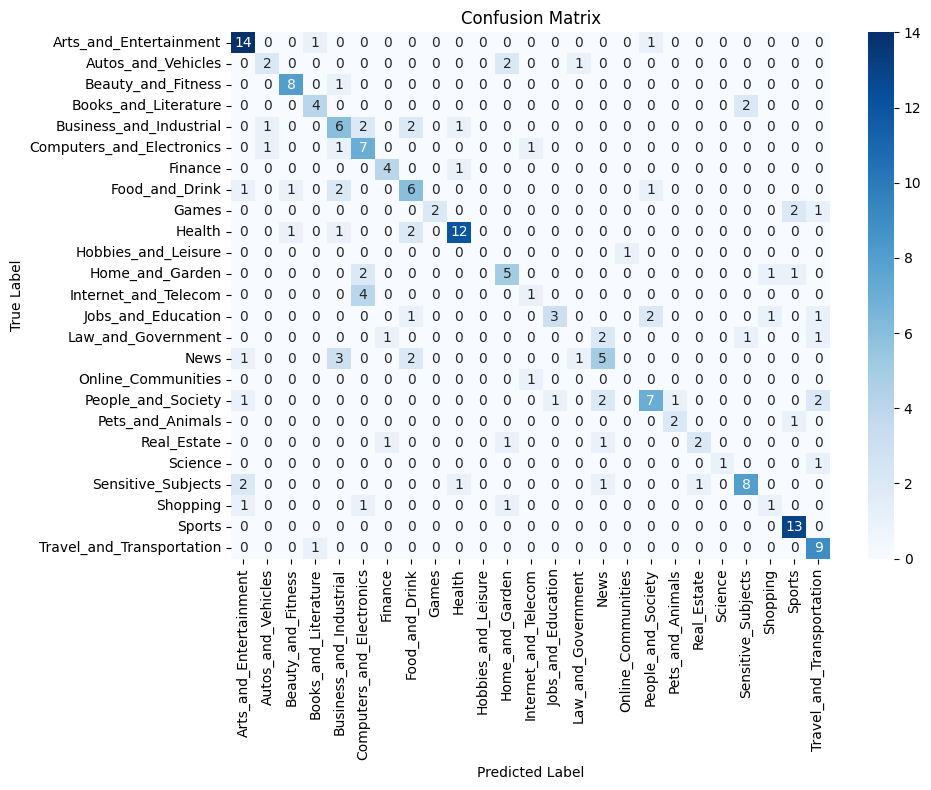

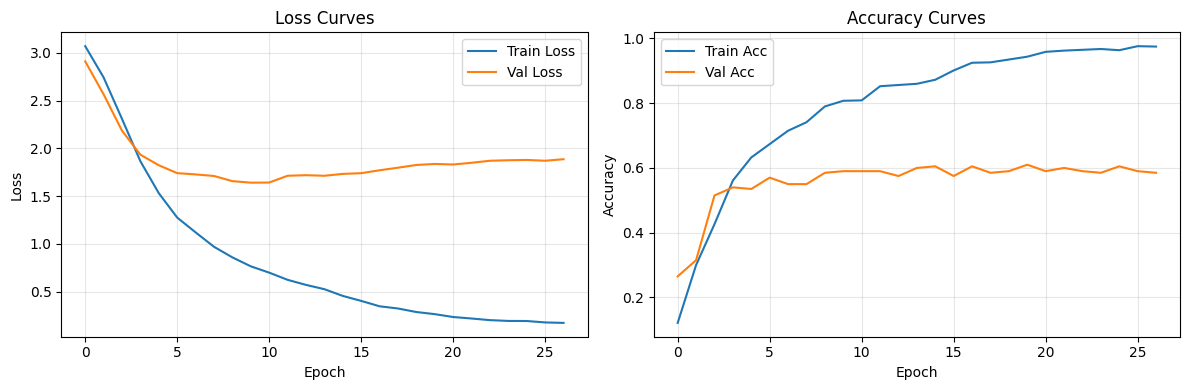


✅ Training complete!
   Best model: models\han_best.pt
   Confusion matrix: models\confusion_matrix.png
   Training history: models\training_history.png


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import os
import joblib
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# HAN MODEL
# ============================================================
class WordAttention(nn.Module):
    """Word-level attention layer."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x, mask=None):
        # x: (batch, n_sentences, hidden_size)
        # mask: (batch, n_sentences)
        
        scores = self.attention(x).squeeze(-1)  # (batch, n_sentences)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        weights = torch.softmax(scores, dim=-1)  # (batch, n_sentences)
        context = torch.bmm(weights.unsqueeze(1), x).squeeze(1)  # (batch, hidden_size)
        
        return context, weights


class SentenceAttention(nn.Module):
    """Sentence-level attention layer."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )
    
    def forward(self, x, mask=None):
        # x: (batch, n_docs, hidden_size)
        # mask: (batch, n_docs)
        
        scores = self.attention(x).squeeze(-1)
        
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        
        weights = torch.softmax(scores, dim=-1)
        context = torch.bmm(weights.unsqueeze(1), x).squeeze(1)
        
        return context, weights


class HANClassifier(nn.Module):
    """
    Hierarchical Attention Network for document classification.
    
    Expects pre-computed sentence embeddings as input.
    """
    def __init__(self, hidden_size, num_classes, dropout=0.3):
        super().__init__()
        
        self.word_attention = WordAttention(hidden_size)
        self.sentence_attention = SentenceAttention(hidden_size)
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, sentence_embeddings, sentence_mask):
        """
        Args:
            sentence_embeddings: (batch, max_sentences, hidden_size)
            sentence_mask: (batch, max_sentences) — 1 for valid, 0 for padding
        
        Returns:
            logits: (batch, num_classes)
            word_attn_weights: (batch, max_sentences)
        """
        # Sentence-level attention
        doc_vector, sent_attn_weights = self.sentence_attention(
            sentence_embeddings, sentence_mask
        )
        
        doc_vector = self.dropout(doc_vector)
        
        # Classification
        logits = self.classifier(doc_vector)
        
        return logits, sent_attn_weights


# ============================================================
# DATASET
# ============================================================
class EmbeddingDataset(Dataset):
    """Dataset for pre-computed embeddings."""
    def __init__(self, embeddings, masks, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.masks = torch.FloatTensor(masks)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.embeddings[idx], self.masks[idx], self.labels[idx]


# ============================================================
# TRAINING LOOP
# ============================================================
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for embeddings, masks, labels in dataloader:
        embeddings = embeddings.to(device)
        masks = masks.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        logits, _ = model(embeddings, masks)
        loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_attentions = []
    
    with torch.no_grad():
        for embeddings, masks, labels in dataloader:
            embeddings = embeddings.to(device)
            masks = masks.to(device)
            labels = labels.to(device)
            
            logits, attn_weights = model(embeddings, masks)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_attentions.append(attn_weights.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy, all_preds, all_labels, np.concatenate(all_attentions)


# ============================================================
# MAIN TRAINING SCRIPT
# ============================================================
def main():
    # --- Configuration ---
    DATA_DIR = 'data'
    MODEL_SAVE_DIR = 'models'
    BATCH_SIZE = 32
    LEARNING_RATE = 1e-3
    N_EPOCHS = 50
    PATIENCE = 7  # Early stopping
    DROPOUT = 0.2
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n{'='*60}")
    print(f"🚀 HAN Training")
    print(f"{'='*60}")
    print(f"💻 Device: {device}")
    
    os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
    
    # --- Load embeddings ---
    print(f"\n📂 Loading embeddings from '{DATA_DIR}/'...")
    train_data = np.load(os.path.join(DATA_DIR, 'train_embeddings.npz'))
    val_data = np.load(os.path.join(DATA_DIR, 'val_embeddings.npz'))
    label_encoder = joblib.load(os.path.join(DATA_DIR, 'label_encoder.joblib'))
    
    train_embeddings = train_data['embeddings']
    train_masks = train_data['masks']
    train_labels = train_data['labels']
    
    val_embeddings = val_data['embeddings']
    val_masks = val_data['masks']
    val_labels = val_data['labels']
    
    num_classes = len(label_encoder.classes_)
    hidden_size = train_embeddings.shape[2]
    
    print(f"   Train: {train_embeddings.shape}")
    print(f"   Val:   {val_embeddings.shape}")
    print(f"   Classes: {num_classes} → {list(label_encoder.classes_)}")
    print(f"   Hidden size: {hidden_size}")
    
    # --- Create dataloaders ---
    train_dataset = EmbeddingDataset(train_embeddings, train_masks, train_labels)
    val_dataset = EmbeddingDataset(val_embeddings, val_masks, val_labels)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    print(f"\n📊 DataLoaders:")
    print(f"   Train: {len(train_loader)} batches")
    print(f"   Val:   {len(val_loader)} batches")
    
    # --- Initialize model ---
    model = HANClassifier(
        hidden_size=hidden_size,
        num_classes=num_classes,
        dropout=DROPOUT
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=3
    )
    
    print(f"\n🤖 Model: HANClassifier")
    print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")
    print(f"   Dropout: {DROPOUT}")
    print(f"   LR: {LEARNING_RATE}")
    
    # --- Training loop ---
    print(f"\n{'='*60}")
    print(f"🎯 Training")
    print(f"{'='*60}")
    
    best_val_acc = 0
    patience_counter = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(1, N_EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc, val_preds, val_true, _ = evaluate(model, val_loader, criterion, device)
        
        scheduler.step(val_acc)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch:2d}/{N_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}", end='')
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_acc': val_acc,
                'hidden_size': hidden_size,
                'num_classes': num_classes,
                # label_encoder saved separately in data/ -- no need here
            }, os.path.join(MODEL_SAVE_DIR, 'han_best.pt'))
            print(f" ✅ (saved, new best)")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f" (patience {patience_counter}/{PATIENCE})")
        
        if patience_counter >= PATIENCE:
            print(f"\n⏹️  Early stopping triggered at epoch {epoch}")
            break
    
    # --- Final evaluation ---
    print(f"\n{'='*60}")
    print(f"📊 Final Evaluation (Best Model)")
    print(f"{'='*60}")
    
    # Load best model
    checkpoint = torch.load(os.path.join(MODEL_SAVE_DIR, 'han_best.pt'), weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    _, _, val_preds, val_true, val_attentions = evaluate(model, val_loader, criterion, device)
    
    print(f"\n📈 Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"\n📋 Classification Report:")
    print(classification_report(
        val_true, val_preds,
        target_names=label_encoder.classes_,
        digits=4
    ))
    
    # Confusion matrix
    cm = confusion_matrix(val_true, val_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png'))
    plt.show()
    
    # Plot training history
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].set_title('Loss Curves')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].set_title('Accuracy Curves')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_SAVE_DIR, 'training_history.png'))
    plt.show()
    
    print(f"\n✅ Training complete!")
    print(f"   Best model: {os.path.join(MODEL_SAVE_DIR, 'han_best.pt')}")
    print(f"   Confusion matrix: {os.path.join(MODEL_SAVE_DIR, 'confusion_matrix.png')}")
    print(f"   Training history: {os.path.join(MODEL_SAVE_DIR, 'training_history.png')}")


# ============================================================
# INFERENCE EXAMPLE
# ============================================================
def predict_text(text, model, embedder, label_encoder, max_sentences=40, device='cpu'):
    """
    Predict domain for a new text.
    """
    from pipeline import split_and_segment  # Or import from your module
    
    # Split and segment
    sentences = split_and_segment(text)[:max_sentences]
    
    if len(sentences) == 0:
        return "unknown", 0.0
    
    # Create embedding matrix
    sent_embs = embedder.encode_document(sentences, max_sentences=max_sentences)
    sent_embs = torch.FloatTensor(sent_embs).unsqueeze(0).to(device)  # (1, max_sentences, hidden)
    
    mask = torch.zeros(1, max_sentences, device=device)
    mask[0, :len(sentences)] = 1
    
    model.eval()
    with torch.no_grad():
        logits, attn_weights = model(sent_embs, mask)
        probs = torch.softmax(logits, dim=1)
        pred_idx = torch.argmax(logits, dim=1).item()
        confidence = probs[0, pred_idx].item()
    
    predicted_domain = label_encoder.classes_[pred_idx]
    return predicted_domain, confidence


# ============================================================
# RUN
# ============================================================
if __name__ == "__main__":
    main()